Statistical Analysis & Hypothesis Testing


T-test: Compares mean between 2 categories

Anova: Compare means with 3 or more categories

Chi-Squared: Test if 2 categories are related

Correlation Test: Measure associatoin between 2 numerical values (our data only has one aka CGPA so we would have to convert a category to numerical value to use this)

In [40]:
#Imports
from pathlib import Path
import pandas as pd
import scipy.stats as stats
from scipy.stats import ttest_ind, f_oneway, chi2_contingency, pearsonr, spearmanr
import matplotlib.pyplot as plt
import seaborn as sns

# Getting Dataset
data = pd.read_excel(Path("..") / "stage1" / "data.xlsx")
data.head()

,Education Level,Specialization,Skills,Certifications,CGPA/Percentage,Recommended Career
0,Bachelor's,Finance,"Counseling, MS Office, Machine Learning",Tally ERP,67,Business Analyst
1,Intermediate,Science,"Accounting, MS Office",AWS Certified,67,Software Engineer
2,Master's,Business,"Accounting, SQL, Data Analysis",Mental Health Basics,90,Financial Analyst
3,Bachelor's,Computer Science,Communication,NaN,75,Clerk
4,Matric,Business,Data Analysis,Tally ERP,83,Sales Assistant


In [41]:
# T-Test for Comparing Means of Two Groups
group1 = data[data["Recommended Career"] == "Software Engineer"]["CGPA/Percentage"]
group2 = data[data["Recommended Career"] == "Clerk"]["CGPA/Percentage"]

t_stat, p_value = ttest_ind(group1, group2, equal_var=False)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: -0.6015562346279915
P-value: 0.5476311241831193


Software Engineer Mean: 76.77
Clerk Mean: 77.20


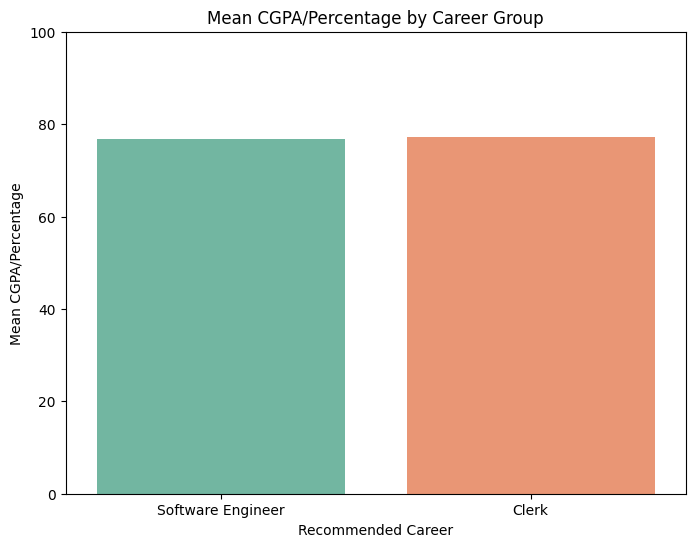

In [39]:
# Bar Graph with mean for both groups see difference before t-test
engineer_mean = data[data["Recommended Career"] == "Software Engineer"]["CGPA/Percentage"].mean()
clerk_mean = data[data["Recommended Career"] == "Clerk"]["CGPA/Percentage"].mean()
careers = ["Software Engineer", "Clerk"]
means = [engineer_mean, clerk_mean]
print(f"Software Engineer Mean: {engineer_mean:.2f}")
print(f"Clerk Mean: {clerk_mean:.2f}")

plt.figure(figsize=(8, 6))
sns.barplot(x=careers, y=means, hue=careers, palette="Set2", legend=False)
plt.ylabel("Mean CGPA/Percentage")
plt.xlabel("Recommended Career")
plt.title("Mean CGPA/Percentage by Career Group")
plt.ylim(0, 100)
plt.show()

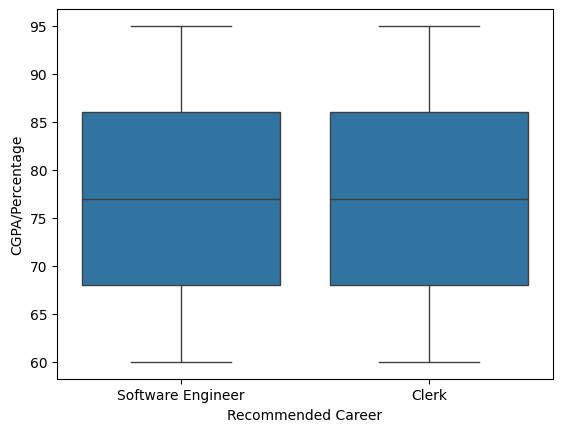

In [ ]:
# Box Plot to visualize distribution and outliers
filtered_data = data[data["Recommended Career"].isin(["Software Engineer","Clerk"])]
sns.boxplot(x="Recommended Career", y="CGPA/Percentage", data=filtered_data)
plt.show()

Using a T-test to compare mean CGPA/Percentage between "Software Engineer" and "Clerk" career groups. The null hypothesis states that the mean CGPA/Percentage is the same for both groups, and the alternate hypothesis states that the means are different. Our P-value of 0.5476311241831193 is greater than 0.05, telling us that we failed to reject the null hypothesis. There is not enough evidence to support a difference in mean CGPA/Percentage between the two categories choosen. The mean average of both categories are similar. 

In [ ]:
# Chi-Square Test of Independence

# Contingency table of Specilization vs Recommended Career (Degree of freedom 1)
table = pd.crosstab(data["Specialization"], data["Recommended Career"])

# Chi-square test to test if the 2 categories are related
chi2, p, dof, expected = stats.chi2_contingency(table)

print("Chi-square Statistic:", chi2)
print("p-value:", p)
print("Degrees of Freedom:", dof)

Chi-square Statistic: 84.93879861861754
p-value: 0.2507014727049615
Degrees of Freedom: 77


Using Chi-Squared test of independence to compare "Specilizatoin" and "Recommended Career". Null hypothesis(P-value ≤ 0.05) states that the variables are independent and alternate hypothesis (P-value > 0.05) state that there is a relation. Our P-value of 0.20192815982635112 is greater than .05 letting us know that we failed to reject the null hypothesis. There is not enough evidence to support a relation between our 2 categories. Chi-squared value by it'self can't be interepted accurately. 
